In [6]:
import numpy as np
from tensorflow.keras.datasets import imdb


In [7]:
max_features = 1000
imdb.load_data(num_words=max_features)

c:\Users\Hp\OneDrive\Desktop\GenAI---\rnnenv\Lib\site-packages\numpy\lib\_format_impl.py:838: VisibleDeprecationWarning: dtype(): align should be passed as Python or NumPy boolean but got `align=0`. Did you mean to pass a tuple to create a subarray type? (Deprecated NumPy 2.4)
  array = pickle.load(fp, **pickle_kwargs)


((array([list([1, 14, 22, 16, 43, 530, 973, 2, 2, 65, 458, 2, 66, 2, 4, 173, 36, 256, 5, 25, 100, 43, 838, 112, 50, 670, 2, 9, 35, 480, 284, 5, 150, 4, 172, 112, 167, 2, 336, 385, 39, 4, 172, 2, 2, 17, 546, 38, 13, 447, 4, 192, 50, 16, 6, 147, 2, 19, 14, 22, 4, 2, 2, 469, 4, 22, 71, 87, 12, 16, 43, 530, 38, 76, 15, 13, 2, 4, 22, 17, 515, 17, 12, 16, 626, 18, 2, 5, 62, 386, 12, 8, 316, 8, 106, 5, 4, 2, 2, 16, 480, 66, 2, 33, 4, 130, 12, 16, 38, 619, 5, 25, 124, 51, 36, 135, 48, 25, 2, 33, 6, 22, 12, 215, 28, 77, 52, 5, 14, 407, 16, 82, 2, 8, 4, 107, 117, 2, 15, 256, 4, 2, 7, 2, 5, 723, 36, 71, 43, 530, 476, 26, 400, 317, 46, 7, 4, 2, 2, 13, 104, 88, 4, 381, 15, 297, 98, 32, 2, 56, 26, 141, 6, 194, 2, 18, 4, 226, 22, 21, 134, 476, 26, 480, 5, 144, 30, 2, 18, 51, 36, 28, 224, 92, 25, 104, 4, 226, 65, 16, 38, 2, 88, 12, 16, 283, 5, 16, 2, 113, 103, 32, 15, 16, 2, 19, 178, 32]),
         list([1, 194, 2, 194, 2, 78, 228, 5, 6, 2, 2, 2, 134, 26, 4, 715, 8, 118, 2, 14, 394, 20, 13, 119, 954, 

In [8]:
(x_train, y_train), (x_test, y_test) = imdb.load_data(num_words=max_features)

print(f"Training data shape: {len(x_train)}, Training labels shape: {len(y_train)}")
print(f"Test data shape: {len(x_test)}, Test labels shape: {len(y_test)}")

Training data shape: 25000, Training labels shape: 25000
Test data shape: 25000, Test labels shape: 25000


In [9]:
x=np.concatenate((x_train, x_test), axis=0)
y=np.concatenate((y_train, y_test), axis=0)

In [10]:
split_index=int(0.8 * len(x))
x_train=x[:split_index]
y_train=y[:split_index]

In [11]:
print("Training Samples:",len(x_train))
print("Training Labels:",len(y_train))

Training Samples: 40000
Training Labels: 40000


In [12]:
print(x_train[0])
print(y_train[0])


[1, 14, 22, 16, 43, 530, 973, 2, 2, 65, 458, 2, 66, 2, 4, 173, 36, 256, 5, 25, 100, 43, 838, 112, 50, 670, 2, 9, 35, 480, 284, 5, 150, 4, 172, 112, 167, 2, 336, 385, 39, 4, 172, 2, 2, 17, 546, 38, 13, 447, 4, 192, 50, 16, 6, 147, 2, 19, 14, 22, 4, 2, 2, 469, 4, 22, 71, 87, 12, 16, 43, 530, 38, 76, 15, 13, 2, 4, 22, 17, 515, 17, 12, 16, 626, 18, 2, 5, 62, 386, 12, 8, 316, 8, 106, 5, 4, 2, 2, 16, 480, 66, 2, 33, 4, 130, 12, 16, 38, 619, 5, 25, 124, 51, 36, 135, 48, 25, 2, 33, 6, 22, 12, 215, 28, 77, 52, 5, 14, 407, 16, 82, 2, 8, 4, 107, 117, 2, 15, 256, 4, 2, 7, 2, 5, 723, 36, 71, 43, 530, 476, 26, 400, 317, 46, 7, 4, 2, 2, 13, 104, 88, 4, 381, 15, 297, 98, 32, 2, 56, 26, 141, 6, 194, 2, 18, 4, 226, 22, 21, 134, 476, 26, 480, 5, 144, 30, 2, 18, 51, 36, 28, 224, 92, 25, 104, 4, 226, 65, 16, 38, 2, 88, 12, 16, 283, 5, 16, 2, 113, 103, 32, 15, 16, 2, 19, 178, 32]
1


In [13]:
from tensorflow.keras.preprocessing import sequence
maxlen = 500
x_train = sequence.pad_sequences(x_train, maxlen=maxlen)
x_test = sequence.pad_sequences(x_test, maxlen=maxlen)
print(x_train.shape)

(40000, 500)


In [14]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, SimpleRNN, Dense
model=Sequential()
model.add(Embedding(input_dim=max_features, output_dim=128))

In [15]:
model.add(SimpleRNN(128,activation='tanh'))
model.add(Dense(1,activation='sigmoid'))

In [16]:
model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn (SimpleRNN)          │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [17]:
from tensorflow.keras.callbacks import EarlyStopping
early_stopping = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)

In [19]:
history = model.fit(x_train, y_train, epochs=10, batch_size=32, validation_split=0.2,callbacks=[early_stopping])

Epoch 1/10
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 97s 97ms/step - accuracy: 0.6059 - loss: 0.6508 - val_accuracy: 0.5552 - val_loss: 0.6863
Epoch 2/10
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 89s 89ms/step - accuracy: 0.6549 - loss: 0.6141 - val_accuracy: 0.5735 - val_loss: 0.6502
Epoch 3/10
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 89s 89ms/step - accuracy: 0.6637 - loss: 0.6015 - val_accuracy: 0.7189 - val_loss: 0.5588
Epoch 4/10
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 87s 87ms/step - accuracy: 0.7048 - loss: 0.5667 - val_accuracy: 0.6664 - val_loss: 0.5935
Epoch 5/10
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 88s 88ms/step - accuracy: 0.6868 - loss: 0.5753 - val_accuracy: 0.7383 - val_loss: 0.6077
Epoch 6/10
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 86s 86ms/step - accuracy: 0.7391 - loss: 0.5291 - val_accuracy: 0.7084 - val_loss: 0.5798
Epoch 7/10
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 87s 87ms/step - accuracy: 0.7243 - loss: 0.5542 - val_accuracy: 0.7197 - val_loss: 0.5658
Epoch 8/10
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 81s 81ms/step - accuracy: 0.7580 -

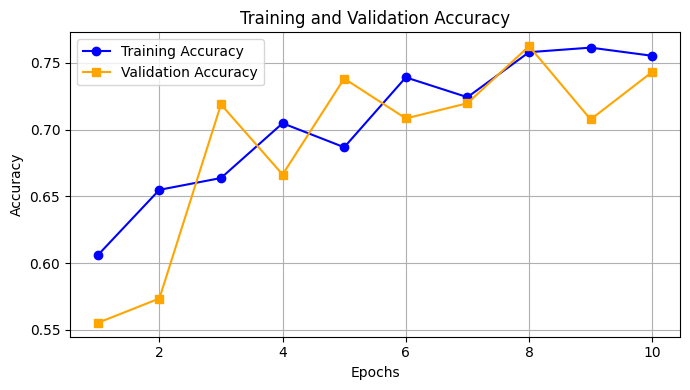

In [20]:
import matplotlib.pyplot as plt
accuracy=history.history['accuracy']
val_accuracy=history.history['val_accuracy']
loss=history.history['loss']
val_loss=history.history['val_loss']
epochs=range(1,len(accuracy)+1)
plt.figure(figsize=(7,4))
plt.plot(epochs, accuracy, color='blue',marker='o', label='Training Accuracy')
plt.plot(epochs, val_accuracy, color='orange', marker='s',label='Validation Accuracy')

plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.title('Training and Validation Accuracy')
plt.legend()
plt.grid(True)
plt.tight_layout()

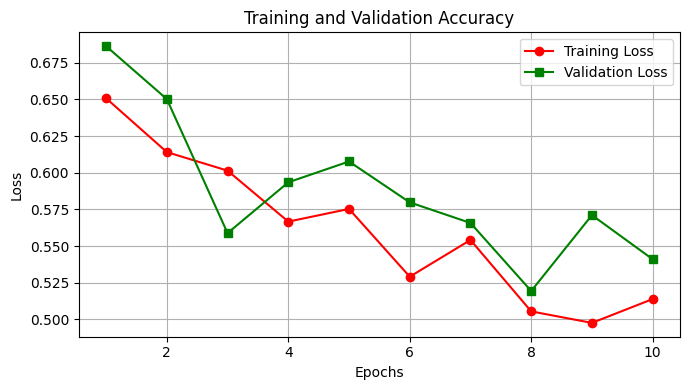

In [21]:
plt.figure(figsize=(7,4))
plt.plot(epochs, loss, color='red', marker='o', label='Training Loss')
plt.plot(epochs, val_loss, color='green', marker='s',label='Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('Training and Validation Accuracy')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

In [22]:
model.save('simple_rnn_model.h5')

In [23]:
from tensorflow.keras.models import load_model

model = load_model('simple_rnn_model.h5')
model.summary()


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ (32, 500, 128)         │       128,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn (SimpleRNN)          │ (32, 128)              │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (32, 1)                │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 161,027 (629.02 KB)

 Trainable params: 161,025 (629.00 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 2 (12.00 B)

In [24]:
test_loss, test_accuracy = model.evaluate(x_test, y_test)
print(f'Test Loss: {test_loss}')
print(f'Test Accuracy: {test_accuracy}')

782/782 ━━━━━━━━━━━━━━━━━━━━ 17s 21ms/step - accuracy: 0.7674 - loss: 0.5045
Test Loss: 0.5045163035392761
Test Accuracy: 0.7674400210380554


In [25]:
sample_review = x_test[1]
sample_review 

array([  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
         0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
         0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
         0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
         0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
         0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
         0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
         0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
         0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
         0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
         0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
         0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
         0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
         0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   

In [26]:
len(sample_review.reshape(1, -1))

1

In [27]:
prediction = model.predict(sample_review.reshape(1, -1))
prediction

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 176ms/step


array([[0.88282657]], dtype=float32)

In [28]:
sentiment='positive' if prediction[0][0]>=0.5 else 'negative'
print(f'The review is predicted to be {sentiment}.')
print('Predicted Score:',prediction[0][0])

The review is predicted to be positive.
Predicted Score: 0.88282657


In [29]:
print('Actual Label:', 'positive' if y_test[1]==1 else 'negative')

Actual Label: positive
